# Day 3 — Raw Data Exploration & Baseline Model

**Goal:** Transform raw data from ingestion into a feature-engineered dataset and train a baseline model for flood prediction.

**Objectives:**
1. Load raw weather and flood data.
2. Implement 6-hourly resampling.
3. Apply advanced feature engineering (Lags, Rolling Sums, API, Seasonal).
4. Train a baseline Random Forest model.
5. Validate model performance with Cross-Validation.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, auc, make_scorer, recall_score, precision_score
)
import os
import joblib

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1. Data Ingestion (Raw)
Loading raw parquet files into DuckDB for efficient SQL-based transformations.

In [2]:
conn = duckdb.connect(':memory:')

# Load raw weather files (fixing path to be relative to notebook location)
conn.execute("""
    CREATE OR REPLACE VIEW weather_raw AS 
    SELECT * FROM read_parquet('../data/raw/weather_raw_*.parquet');
""")

# Load raw flood files
conn.execute("""
    CREATE OR REPLACE VIEW flood_raw AS 
    SELECT * FROM read_parquet('../data/raw/flood_raw_*.parquet');
""")

conn.execute("SELECT zone, count(*) FROM weather_raw GROUP BY 1").df()

,zone,count_star()
0,Urban,55248
1,Coastal,55248
2,Highland,55248


## 2. Feature Engineering
Implementing the 6-hourly features and derived indicators.

In [3]:
# 1. Base 6h Resampling
conn.execute("""
CREATE OR REPLACE TABLE silver_base AS
WITH resampled_weather AS (
    SELECT 
        zone,
        time_bucket(INTERVAL '6 hours', time) AS time_6h,
        AVG(temperature_2m) AS temperature_2m,
        AVG(relative_humidity_2m) AS relative_humidity_2m,
        SUM(precipitation) AS precipitation,
        AVG(soil_moisture_0_to_7cm) AS soil_moisture_0_to_7cm,
        AVG(soil_moisture_7_to_28cm) AS soil_moisture_7_to_28cm,
        AVG(soil_temperature_0_to_7cm) AS soil_temperature_0_to_7cm,
        SUM(et0_fao_evapotranspiration) AS et0_fao_evapotranspiration
    FROM weather_raw
    GROUP BY 1, 2
),
resampled_flood AS (
    SELECT 
        zone,
        CAST(time AS DATE) AS date_key,
        MAX(river_discharge) AS river_discharge
    FROM flood_raw
    GROUP BY 1, 2
)
SELECT 
    w.*,
    COALESCE(f.river_discharge, 0.0) AS river_discharge
FROM resampled_weather w
LEFT JOIN resampled_flood f 
    ON w.zone = f.zone 
    AND CAST(w.time_6h AS DATE) = f.date_key;
""")

# 2. Advanced Derived Features
conn.execute("""
CREATE OR REPLACE TABLE gold_features AS
WITH lagged AS (
    SELECT 
        *,
        -- Lags
        LAG(precipitation, 1) OVER (PARTITION BY zone ORDER BY time_6h) AS precip_lag_6h,
        LAG(precipitation, 2) OVER (PARTITION BY zone ORDER BY time_6h) AS precip_lag_12h,
        LAG(precipitation, 4) OVER (PARTITION BY zone ORDER BY time_6h) AS precip_lag_24h,
        LAG(precipitation, 8) OVER (PARTITION BY zone ORDER BY time_6h) AS precip_lag_48h,
        LAG(river_discharge, 1) OVER (PARTITION BY zone ORDER BY time_6h) AS discharge_lag_6h,
        LAG(river_discharge, 4) OVER (PARTITION BY zone ORDER BY time_6h) AS discharge_lag_24h,
        LAG(temperature_2m, 4) OVER (PARTITION BY zone ORDER BY time_6h) AS temp_lag_24h,
        -- Rolling
        SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS precip_roll_sum_24h,
        SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 7 PRECEDING AND CURRENT ROW) AS precip_roll_sum_48h,
        SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 11 PRECEDING AND CURRENT ROW) AS precip_roll_sum_72h,
        MAX(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS precip_roll_max_24h,
        MAX(river_discharge) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS discharge_roll_max_24h,
        MAX(relative_humidity_2m) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS humidity_roll_max_24h,
        SUM(et0_fao_evapotranspiration) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS et0_roll_sum_24h
    FROM silver_base
),
api_calc AS (
    -- Simple API calculation (Antecedent Precipitation Index)
    -- Using 0.85 decay over 4 buckets (24h) for simplification in SQL
    SELECT 
        *,
        (precipitation + 0.85 * COALESCE(precip_lag_6h, 0) + 0.85^2 * COALESCE(precip_lag_12h, 0) + 0.85^4 * COALESCE(precip_lag_24h, 0)) AS api_7d,
        (soil_moisture_0_to_7cm + soil_moisture_7_to_28cm) / 2 AS soil_saturation_index
    FROM lagged
),
additional_derived AS (
    SELECT
        *,
        soil_moisture_0_to_7cm - LAG(soil_moisture_0_to_7cm, 1) OVER (PARTITION BY zone ORDER BY time_6h) AS soil_moisture_change_6h,
        0.45 - soil_saturation_index AS soil_moisture_deficit,
        CASE WHEN soil_temperature_0_to_7cm < 0 THEN 1 ELSE 0 END AS frozen_ground_flag,
        river_discharge - discharge_lag_6h AS discharge_trend_6h,
        temperature_2m - temp_lag_24h AS temp_trend_24h,
        precipitation - et0_fao_evapotranspiration AS et_deficit_6h,
        precip_roll_sum_24h - et0_roll_sum_24h AS et_deficit_24h,
        relative_humidity_2m * precipitation AS humidity_precip_product
    FROM api_calc
),
highland_context AS (
    -- Cross-zone features: Get Highland data for others
    SELECT 
        time_6h,
        precip_roll_sum_24h AS highland_precip_24h,
        river_discharge AS highland_discharge_6h
    FROM additional_derived
    WHERE zone = 'Highland'
)
SELECT 
    d.*,
    h.highland_precip_24h,
    h.highland_discharge_6h,
    CASE 
        WHEN d.zone = 'Highland' THEN d.precip_roll_sum_24h * (1/3.0)
        WHEN d.zone = 'Urban' THEN h.highland_precip_24h * (1/1.5)
        ELSE h.highland_precip_24h * (1/1.0)
    END AS zone_cascade_risk,
    -- Seasonal Features
    SIN(2 * PI() * EXTRACT(HOUR FROM d.time_6h) / 24) AS hour_sin,
    COS(2 * PI() * EXTRACT(HOUR FROM d.time_6h) / 24) AS hour_cos,
    SIN(2 * PI() * EXTRACT(DOY FROM d.time_6h) / 365) AS doy_sin,
    COS(2 * PI() * EXTRACT(DOY FROM d.time_6h) / 365) AS doy_cos,
    CASE WHEN EXTRACT(MONTH FROM d.time_6h) IN (11, 12, 1, 2) THEN 1 ELSE 0 END AS is_winter,
    -- Target
    CASE WHEN river_discharge > 1.0 AND (precipitation > 1.0 OR relative_humidity_2m > 85) THEN 1 ELSE 0 END AS is_flood
FROM additional_derived d
LEFT JOIN highland_context h ON d.time_6h = h.time_6h;
""")

df = conn.execute("SELECT * FROM gold_features WHERE precip_lag_48h IS NOT NULL").df()
print(f"Final dataset shape: {df.shape}")
df.head()

Final dataset shape: (27600, 43)


,zone,time_6h,temperature_2m,relative_humidity_2m,precipitation,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,river_discharge,precip_lag_6h,precip_lag_12h,precip_lag_24h,precip_lag_48h,discharge_lag_6h,discharge_lag_24h,temp_lag_24h,precip_roll_sum_24h,precip_roll_sum_48h,precip_roll_sum_72h,precip_roll_max_24h,discharge_roll_max_24h,humidity_roll_max_24h,et0_roll_sum_24h,api_7d,soil_saturation_index,soil_moisture_change_6h,soil_moisture_deficit,frozen_ground_flag,discharge_trend_6h,temp_trend_24h,et_deficit_6h,et_deficit_24h,humidity_precip_product,highland_precip_24h,highland_discharge_6h,zone_cascade_risk,hour_sin,hour_cos,doy_sin,doy_cos,is_winter,is_flood
0,Urban,2025-08-10 00:00:00,25.433333,82.833333,0.0,0.070000,0.139,27.000000,0.21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.300000,0.0,0.0,0.0,0.0,0.0,82.833333,5.75,0.00000,0.104500,0.000000,0.345500,0,0.0,-0.866667,-0.21,-5.75,0.00,0.0,0.0,0.000000,0.000000e+00,1.000000e+00,-0.628763,-0.777597,0,0
1,Urban,2025-08-10 06:00:00,27.266667,73.000000,0.0,0.070000,0.139,27.866667,1.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.633333,0.0,0.0,0.0,0.0,0.0,82.833333,5.58,0.00000,0.104500,0.000000,0.345500,0,0.0,-0.366667,-1.46,-5.58,0.00,0.0,0.0,0.000000,1.000000e+00,6.123234e-17,-0.628763,-0.777597,0,0
2,Urban,2025-08-10 12:00:00,29.966667,50.500000,0.1,0.070833,0.139,35.183333,3.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.050000,0.1,0.1,0.1,0.1,0.0,82.833333,5.28,0.10000,0.104917,0.000833,0.345083,0,0.0,-0.083333,-2.93,-5.18,5.05,0.1,0.0,0.066667,1.224647e-16,-1.000000e+00,-0.628763,-0.777597,0,0
3,Urban,2025-08-10 18:00:00,27.383333,59.666667,0.0,0.071000,0.139,31.950000,0.82,0.0,0.1,0.0,0.0,0.0,0.0,0.0,26.916667,0.1,0.1,0.1,0.1,0.0,82.833333,5.52,0.08500,0.105000,0.000167,0.345000,0,0.0,0.466667,-0.82,-5.42,0.00,0.1,0.0,0.066667,-1.000000e+00,-1.836970e-16,-0.628763,-0.777597,0,0
4,Urban,2025-08-11 00:00:00,26.150000,71.500000,0.0,0.071167,0.139,27.516667,0.48,0.0,0.0,0.1,0.0,0.0,0.0,0.0,25.433333,0.1,0.1,0.1,0.1,0.0,73.000000,5.79,0.07225,0.105083,0.000167,0.344917,0,0.0,0.716667,-0.48,-5.69,0.00,0.1,0.0,0.066667,0.000000e+00,1.000000e+00,-0.642055,-0.766659,0,0


## 3. Exploratory Data Analysis (EDA)
Checking distributions and correlations.

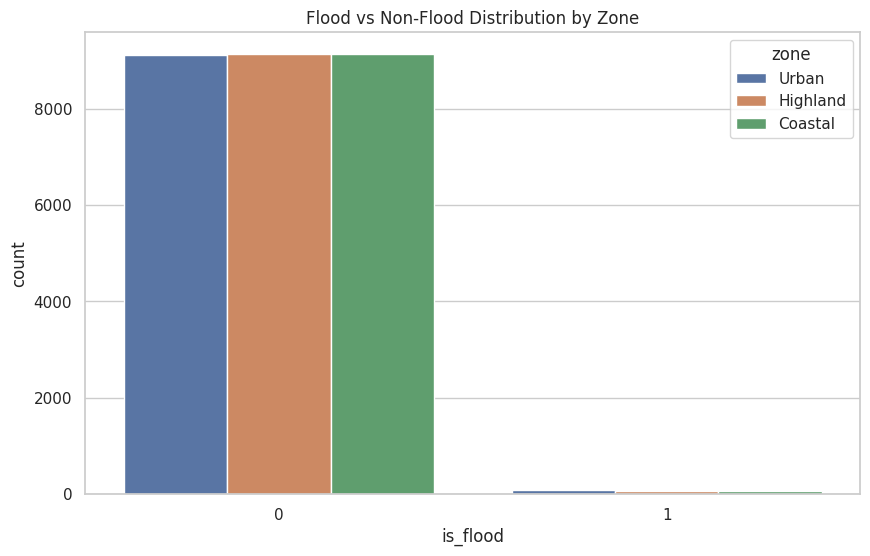

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_flood', data=df, hue='zone')
plt.title('Flood vs Non-Flood Distribution by Zone')
plt.show()

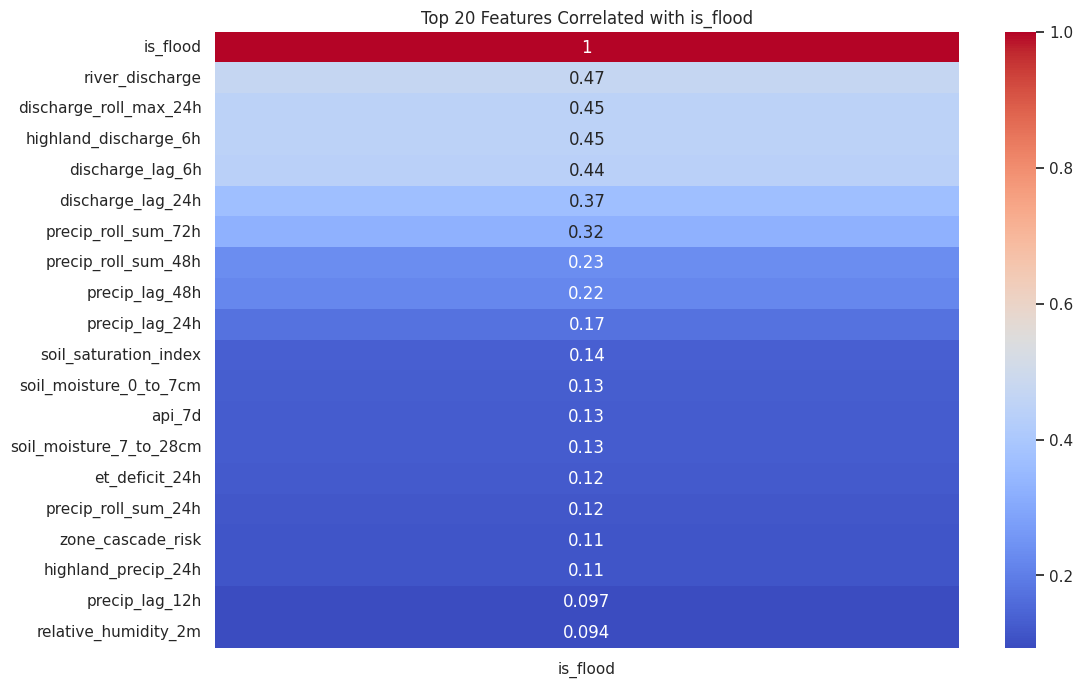

In [5]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr[['is_flood']].sort_values(by='is_flood', ascending=False).head(20), annot=True, cmap='coolwarm')
plt.title('Top 20 Features Correlated with is_flood')
plt.show()

## 4. Model Training (Rare Event Approach)
Using Random Forest with class weighting and Stratified K-Fold Cross-Validation.

Dataset imbalance ratio: 0.0079
Running 5-Fold Stratified Cross-Validation...
CV ROC AUC: 0.9992 (+/- 0.0002)
CV F1-Score: 0.8399

Final Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5477
           1       0.80      0.91      0.85        43

    accuracy                           1.00      5520
   macro avg       0.90      0.95      0.92      5520
weighted avg       1.00      1.00      1.00      5520

PR AUC Score: 0.9287


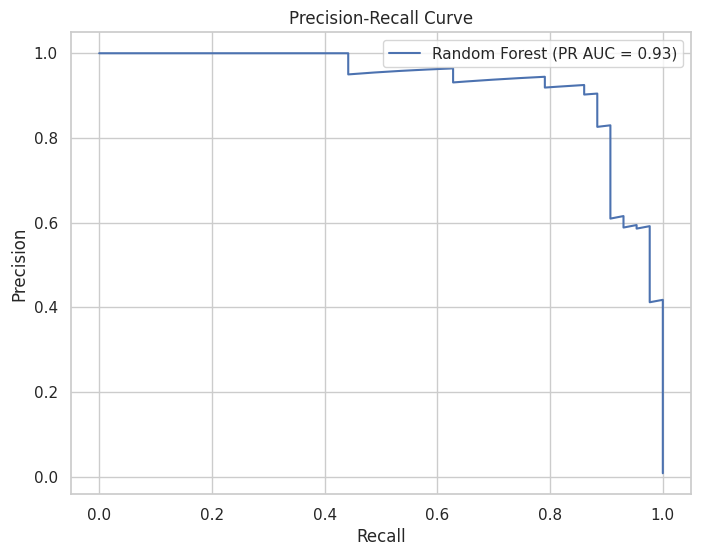

In [6]:
# Prepare features
# Exclude non-input features and temporal identifiers
exclude_cols = ['time_6h', 'is_flood', 'river_discharge', 'temp_lag_24h', 'et0_roll_sum_24h']
X = df.drop(columns=exclude_cols)
y = df['is_flood']

# One-hot encode Zone
X = pd.get_dummies(X, columns=['zone'], drop_first=True)

# Handle NaNs if any (should be few due to LAG filtering)
X = X.fillna(0)

# Split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Dataset imbalance ratio: {y.mean():.4f}")

# Define Model
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced_subsample', 
    max_depth=10,
    random_state=42
)

# 1. Cross-Validation
print("Running 5-Fold Stratified Cross-Validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    rf_model, X_train, y_train, 
    cv=cv, 
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=False
)

print(f"CV ROC AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
print(f"CV F1-Score: {cv_results['test_f1'].mean():.4f}")

# 2. Final Training & Test Evaluation
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_pred))

# Precision-Recall Curve (Better for imbalanced data)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"PR AUC Score: {pr_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Random Forest (PR AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 5. Model Insights

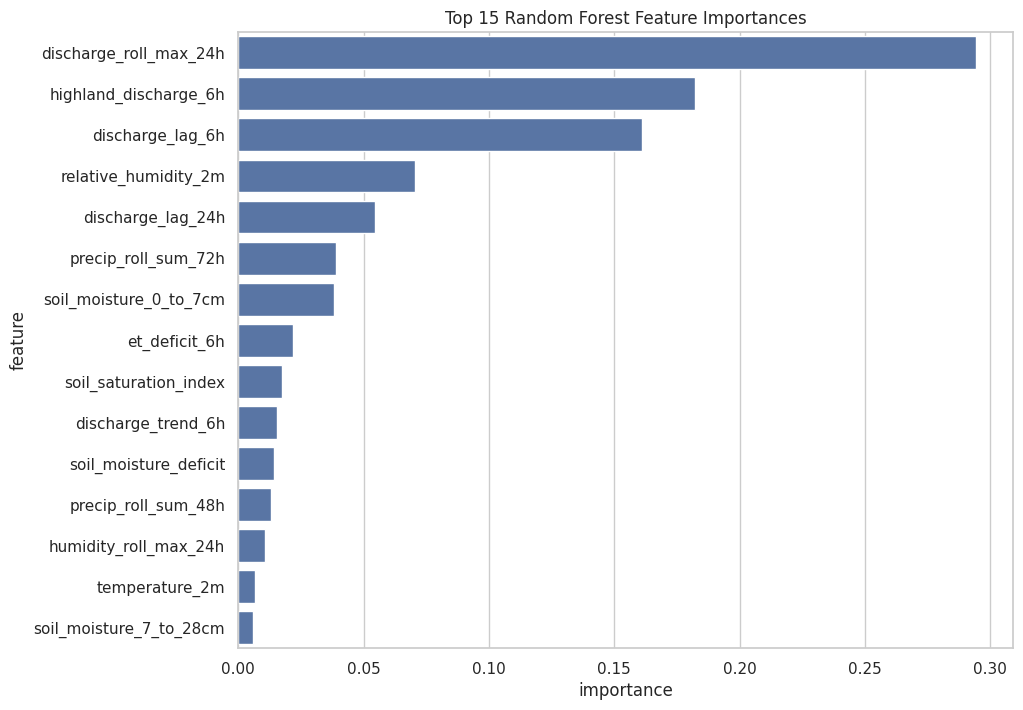

In [7]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Random Forest Feature Importances')
plt.show()

## 6. Save Model for Production
Training on full Gold dataset and saving for Day 4 pipeline.

In [8]:
print("Final training on full dataset...")
rf_model.fit(X, y)

model_path = '../models/baku_sentinel_rf.joblib'
os.makedirs('../models', exist_ok=True)

save_data = {
    'model': rf_model,
    'features': X.columns.tolist()
}

joblib.dump(save_data, model_path)
print(f"Model and feature list saved to {model_path}")

Final training on full dataset...
Model and feature list saved to ../models/baku_sentinel_rf.joblib
